# Kalibracja Kamey i Stereowizja

## Kalibracja pojedynczej kamery

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

class MyCameraCalibration():
    def __init__(self):
        # inner size of chessboard
        self.chess_width = 9
        self.chess_height = 6
        self.chess_square_size = 0.025  # 0.025 meters

        # img size
        self.img_width = 640
        self.img_height = 480
        self.image_size = (self.img_width, self.img_height)

        self.number_of_images = 50

        self.imgpoints = None
        self.objpoints = None

        self.K = None
        self.D = None

        self.map1 = None
        self.map2 = None

    def calcMatrixes(self, path, ifdisplay = False):

        # termination criteria
        criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
        calibration_flags = cv2.fisheye.CALIB_RECOMPUTE_EXTRINSIC + cv2.fisheye.CALIB_FIX_SKEW

        # prepare object points
        objp = np.zeros((self.chess_height * self.chess_width, 1, 3), np.float64)
        objp[:, 0, :2] = np.mgrid[0:self.chess_width, 0:self.chess_height].T.reshape(-1, 2)
        objp = objp * self.chess_square_size  # Create real world coords

        # Arrays to store object points and image points
        objpoints = []  # 3D points in real world space
        imgpoints = []  # 2D points in image plane

        for i in range(1, self.number_of_images):
            # read image
            img = cv2.imread(path + "%02d.png" % i)
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            
            # Find the chess board corners
            ret, corners = cv2.findChessboardCorners(gray, (self.chess_width, self.chess_height),
                                                    cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_FAST_CHECK +
                                                    cv2.CALIB_CB_NORMALIZE_IMAGE)
            Y, X, channels = img.shape
            
            # Skip images where the corners are too close to edges
            if ret:
                minRx = corners[:, :, 0].min()
                maxRx = corners[:, :, 0].max()
                minRy = corners[:, :, 1].min()
                maxRy = corners[:, :, 1].max()
                border_threshold_x = X / 12
                border_threshold_y = Y / 12
                
                x_thresh_bad = minRx < border_threshold_x
                y_thresh_bad = minRy < border_threshold_y
                
                if x_thresh_bad or y_thresh_bad:
                    continue
                
                # If found, add object points and refine image points
                objpoints.append(objp)
                corners2 = cv2.cornerSubPix(gray, corners, (3, 3), (-1, -1), criteria)
                imgpoints.append(corners2)
                
                if ifdisplay:
                    # Draw and display the corners
                    cv2.drawChessboardCorners(img, (self.chess_width, self.chess_height), corners2, ret)
                    cv2.imshow("Corners", img)
                    cv2.waitKey(10)

            else:
                print("Chessboard couldn’t be detected. Image pair:", i)
                continue

        cv2.destroyAllWindows()
        self.imgpoints = imgpoints
        self.objpoints = objpoints

        # Camera calibration
        N_OK = len(objpoints)
        K = np.zeros((3, 3))
        D = np.zeros((4, 1))
        rvecs = [np.zeros((1, 1, 3), dtype=np.float64) for _ in range(N_OK)]
        tvecs = [np.zeros((1, 1, 3), dtype=np.float64) for _ in range(N_OK)]

        ret, K, D, _, _ = cv2.fisheye.calibrate(
            objpoints,
            imgpoints,
            self.image_size,
            None,
            None,
            rvecs,
            tvecs,
            calibration_flags,
            (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 1e-6)
        )

        print(f"K = {K}")
        print(f"D = {D}")

        self.K = K
        self.D = D

        return K, D
    
    def getMatrixes(self):
        return self.K, self.D
    
    def calc_maps(self):
        # Rectify results
        map1, map2 = cv2.fisheye.initUndistortRectifyMap(self.K, self.D, np.eye(3), self.K, self.image_size, cv2.CV_16SC2)
        
        self.map1 = map1
        self.map2 = map2

        return map1, map2
    
    def undistort(self, I):
        undistorted_image = cv2.remap(
                I, self.map1, self.map2, interpolation=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT
            )
        return undistorted_image
    
    def undistort_stereo(self, I_L, I_R):
        undistorted_image_L = cv2.remap(
                I_L, self.stereomaps[0], self.stereomaps[1], interpolation=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT
            )
        undistorted_image_R = cv2.remap(
                I_R, self.stereomaps[2], self.stereomaps[3], interpolation=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT
            )
        return undistorted_image_L, undistorted_image_R
    
    def safe_undistorted(self, read_path, write_path):

        for i in range(1, self.number_of_images):
            # read image
            img = cv2.imread(read_path + "%02d.png" % i)
            undistorted_image = cv2.remap(
                img, self.map1, self.map2, interpolation=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT
            )
            img = cv2.imwrite(write_path + "%02d.png" % i, undistorted_image)
    
    def display_distorion_coparison(self, distorted_path, undistorted_path):

        for i in range(1, self.number_of_images):
            # read image
            img = cv2.imread(distorted_path + "%02d.png" % i)
            undistorted_img = cv2.imread(undistorted_path + "%02d.png" % i)

            glued_imgs = cv2.hconcat((img, undistorted_img))

            cv2.imshow("Comparison", glued_imgs)
            cv2.waitKey(70)

        cv2.destroyAllWindows()

    def get_stereopoints(self, path_left, path_right):
        # Termination criteria
        criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
        calibration_flags = cv2.fisheye.CALIB_RECOMPUTE_EXTRINSIC + cv2.fisheye.CALIB_FIX_SKEW

        # Prepare object points
        objp = np.zeros((self.chess_height * self.chess_width, 1, 3), np.float64)
        objp[:, 0, :2] = np.mgrid[0:self.chess_width, 0:self.chess_height].T.reshape(-1, 2)
        objp = objp * self.chess_square_size  # Create real-world coordinates

        # Arrays to store object points and image points for both left and right images
        objpoints = []  # 3D points in real-world space
        imgpoints_L = []  # 2D points for left image
        imgpoints_R = []  # 2D points for right image

        for i in range(1, self.number_of_images):
            # Load left and right images
            img_L = cv2.imread(path_left + "%02d.png" % i)
            img_R = cv2.imread(path_right + "%02d.png" % i)

            if img_L is None or img_R is None:
                continue  # Skip if either image is missing

            gray_L = cv2.cvtColor(img_L, cv2.COLOR_BGR2GRAY)
            gray_R = cv2.cvtColor(img_R, cv2.COLOR_BGR2GRAY)

            # Find chessboard corners
            ret_L, corners_L = cv2.findChessboardCorners(gray_L, (self.chess_width, self.chess_height),
                                                        cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_FAST_CHECK +
                                                        cv2.CALIB_CB_NORMALIZE_IMAGE)

            ret_R, corners_R = cv2.findChessboardCorners(gray_R, (self.chess_width, self.chess_height),
                                                        cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_FAST_CHECK +
                                                        cv2.CALIB_CB_NORMALIZE_IMAGE)

            if ret_L and ret_R:
                # Image dimensions
                Y_L, X_L, _ = img_L.shape
                Y_R, X_R, _ = img_R.shape

                # Border threshold to filter out detections too close to edges
                border_threshold_x = X_L / 12
                border_threshold_y = Y_L / 12

                minRx_L, maxRx_L = corners_L[:, :, 0].min(), corners_L[:, :, 0].max()
                minRy_L, maxRy_L = corners_L[:, :, 1].min(), corners_L[:, :, 1].max()

                minRx_R, maxRx_R = corners_R[:, :, 0].min(), corners_R[:, :, 0].max()
                minRy_R, maxRy_R = corners_R[:, :, 1].min(), corners_R[:, :, 1].max()

                # Check if corners are too close to the edges
                x_thresh_bad_L = minRx_L < border_threshold_x or maxRx_L > (X_L - border_threshold_x)
                y_thresh_bad_L = minRy_L < border_threshold_y or maxRy_L > (Y_L - border_threshold_y)

                x_thresh_bad_R = minRx_R < border_threshold_x or maxRx_R > (X_R - border_threshold_x)
                y_thresh_bad_R = minRy_R < border_threshold_y or maxRy_R > (Y_R - border_threshold_y)

                if x_thresh_bad_L or y_thresh_bad_L or x_thresh_bad_R or y_thresh_bad_R:
                    continue  # Skip if corners are too close to edges

                # If found in both images, refine corners and store them
                objpoints.append(objp)

                corners_L_refined = cv2.cornerSubPix(gray_L, corners_L, (3, 3), (-1, -1), criteria)
                corners_R_refined = cv2.cornerSubPix(gray_R, corners_R, (3, 3), (-1, -1), criteria)

                imgpoints_L.append(corners_L_refined)
                imgpoints_R.append(corners_R_refined)

        return objpoints, imgpoints_L, imgpoints_R

    def MystereoRectify(self, left_path, right_path):

        # Convert image points to numpy arrays
        objpoints, imgpointsLeft, imgpointsRight = self.get_stereopoints(left_path, right_path)
        
        image_size = self.image_size
        

        objpoints = np.asarray(objpoints, dtype=np.float64)
        imgpointsLeft = np.asarray(imgpointsLeft, dtype=np.float64)
        imgpointsRight = np.asarray(imgpointsRight, dtype=np.float64)

        K_left, D_left, = self.calcMatrixes(left_path)
        K_right, D_right, = self.calcMatrixes(left_path)

        # Stereo calibration
        (RMS, _, _, _, _, rotationMatrix, translationVector) = cv2.fisheye.stereoCalibrate(
            objpoints, imgpointsLeft, imgpointsRight,
            K_left, D_left,
            K_right, D_right,
            image_size, None, None,
            cv2.CALIB_FIX_INTRINSIC,  # Allow OpenCV to optimize values
            (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.1)
        )

        R2 = np.zeros([3, 3])
        P1 = np.zeros([3, 4])
        P2 = np.zeros([3, 4])
        Q = np.zeros([4, 4])


        # Rectify calibration results
        (leftRectification, rightRectification, leftProjection, rightProjection,
        disparityToDepthMap) = cv2.fisheye.stereoRectify(
            K_left, D_left,
            K_right, D_right,
            image_size,
            rotationMatrix, translationVector,
            0, R2, P1, P2, Q,
            cv2.CALIB_ZERO_DISPARITY, (0, 0), 0, 0
        )

        map1_left, map2_left = cv2.fisheye.initUndistortRectifyMap(
            K_left, D_left, leftRectification,
            leftProjection, image_size, cv2.CV_16SC2
        )
        map1_right, map2_right = cv2.fisheye.initUndistortRectifyMap(
            K_right, D_right, rightRectification,
            rightProjection, image_size, cv2.CV_16SC2
        )

        self.stereomaps = (map1_left, map2_left, map1_right, map2_right)


        for i in range(1, self.number_of_images):
            # Load left and right images
            img_l = cv2.imread(left_path + "%02d.png" % i)
            img_r = cv2.imread(right_path + "%02d.png" % i)

            # Load two images and apply remapping
            dst_L = cv2.remap(img_l, map1_left, map2_left, cv2.INTER_LINEAR)
            dst_R = cv2.remap(img_r, map1_right, map2_right, cv2.INTER_LINEAR)

            # Check rectification by placing images side by side
            N, XX, YY = dst_L.shape[::-1]  # RGB image size
            visRectify = np.zeros((YY, XX * 2, N), np.uint8)  # create a new image with double width
            visRectify[:, 0:XX, :] = dst_L  # left image assignment
            visRectify[:, XX:XX * 2, :] = dst_R  # right image assignment

            # Draw horizontal lines
            for y in range(0, YY, 10):
                cv2.line(visRectify, (0, y), (XX * 2, y), (255, 0, 0))

            # Display the rectified image with lines
            cv2.imshow('visRectify', visRectify)
            cv2.waitKey(100)

        cv2.destroyAllWindows()


    

leftCamera = MyCameraCalibration()
rightCamera = MyCameraCalibration()

leftCamera.calcMatrixes("./pairs/left_", False)
rightCamera.calcMatrixes("./pairs/right_", False)

_ = leftCamera.calc_maps()
_ = rightCamera.calc_maps()



K = [[335.39124594   0.         345.29455183]
 [  0.         335.22283549 232.92700067]
 [  0.           0.           1.        ]]
D = [[-0.02430673]
 [-0.018878  ]
 [ 0.02584017]
 [-0.01508828]]
K = [[335.25485233   0.         303.38454349]
 [  0.         334.91067686 245.7103921 ]
 [  0.           0.           1.        ]]
D = [[-0.03570165]
 [ 0.01023055]
 [ 0.00098456]
 [-0.01443733]]


In [4]:
# leftCamera.safe_undistorted("./pairs/left_", "./undistorted_pairs/left_")
# rightCamera.safe_undistorted("./pairs/right_", "./undistorted_pairs/right_")

In [5]:
leftCamera.display_distorion_coparison("./pairs/left_", "./undistorted_pairs/left_")

qt.qpa.plugin: Could not find the Qt platform plugin "wayland" in "/home/jrosa/AGH_FILES/ZAW-2025S/.venv/lib/python3.12/site-packages/cv2/qt/plugins"


## Kalibracja układu kamer

In [6]:
stereoCal = MyCameraCalibration()

stereoCal.MystereoRectify("./pairs/left_", "./pairs/right_")
cv2.destroyAllWindows()

K = [[335.39124594   0.         345.29455183]
 [  0.         335.22283549 232.92700067]
 [  0.           0.           1.        ]]
D = [[-0.02430673]
 [-0.018878  ]
 [ 0.02584017]
 [-0.01508828]]
K = [[335.39124594   0.         345.29455183]
 [  0.         335.22283549 232.92700067]
 [  0.           0.           1.        ]]
D = [[-0.02430673]
 [-0.018878  ]
 [ 0.02584017]
 [-0.01508828]]


## Obliczenia korespondencji stereo

(480, 640) (480, 640)


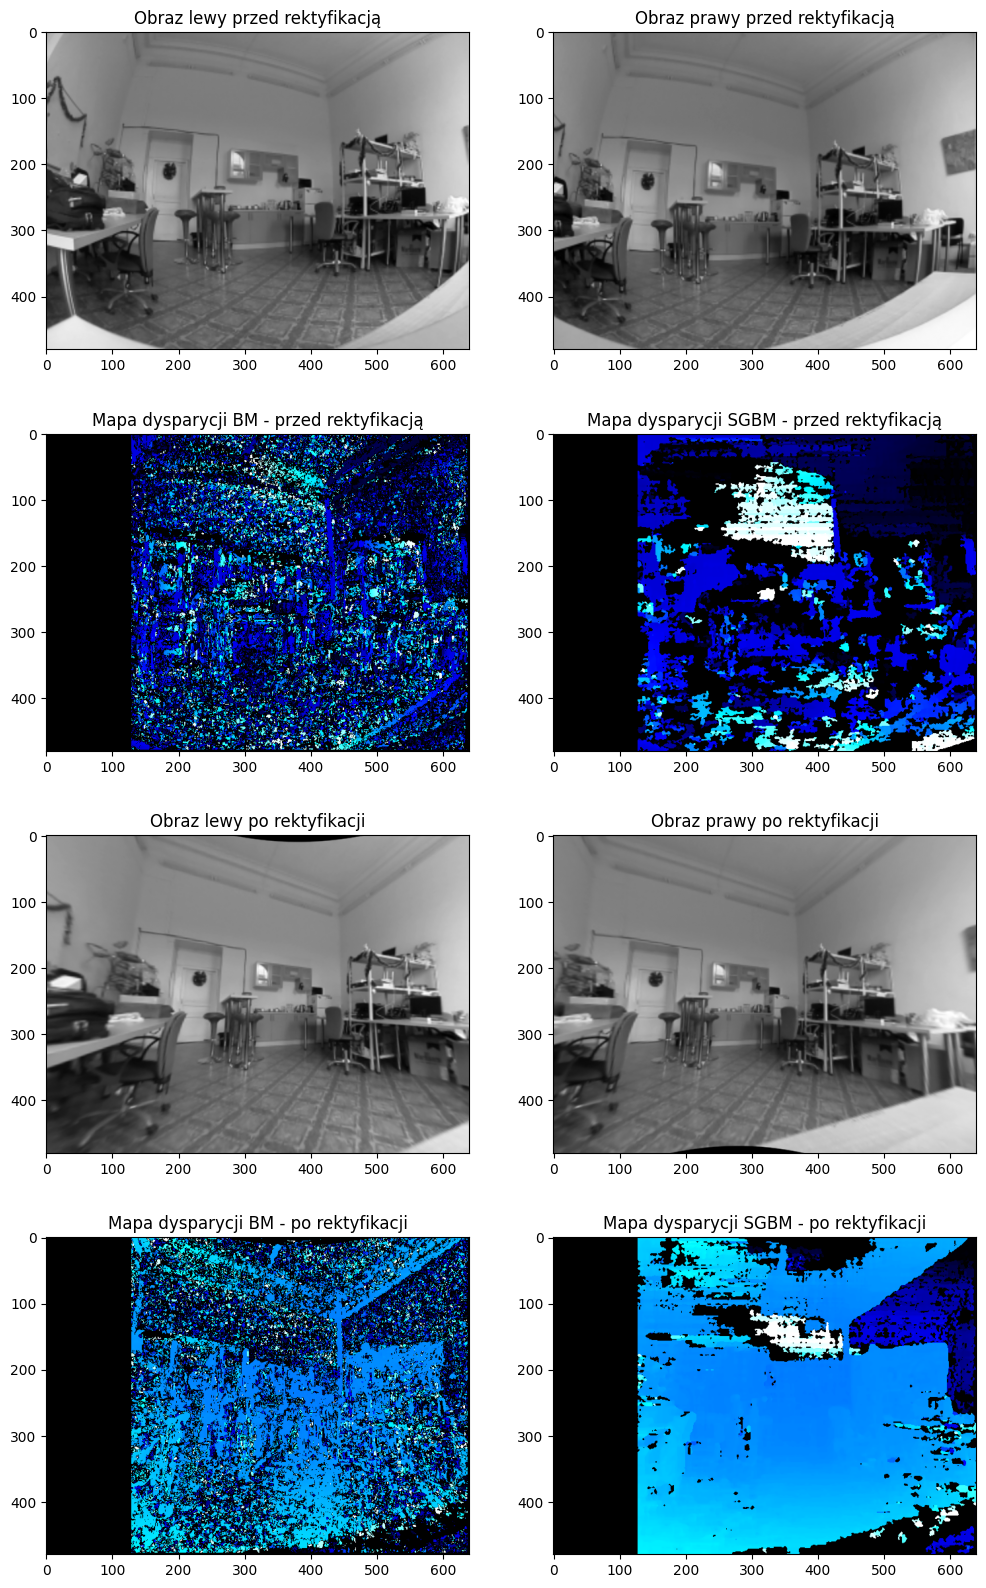

In [14]:
img = cv2.imread("./example/example1.png", cv2.IMREAD_GRAYSCALE)
left_raw = img[:, :img.shape[1]//2]
right_raw = img[:, img.shape[1]//2:]
left_raw =  cv2.resize(left_raw, leftCamera.image_size)
right_raw = cv2.resize(right_raw, rightCamera.image_size)

left_rectified, right_rectified =stereoCal.undistort_stereo(left_raw, right_raw)

print(left_raw.shape, right_raw.shape)

# Parametry dla StereoBM
stereoBM = cv2.StereoBM_create(numDisparities=128, blockSize=5)

# Parametry dla StereoSGBM
min_disp = 0
num_disp = 128  # must be divisible by 16
block_size = 5

stereoSGBM = cv2.StereoSGBM_create(
    minDisparity=min_disp,
    numDisparities=num_disp,
    blockSize=block_size,
    P1=8 * 1 * block_size**2,
    P2=32 * 1 * block_size**2,
    disp12MaxDiff=1,
    uniquenessRatio=10,
    speckleWindowSize=100,
    speckleRange=32,
    preFilterCap=63,
    mode=cv2.STEREO_SGBM_MODE_SGBM_3WAY
)

# Obliczenie mapy dysparycji dla obrazów surowych
dispBM_raw = stereoBM.compute(left_raw, right_raw)
dispSGBM_raw = stereoSGBM.compute(left_raw, right_raw)

# Obliczenie mapy dysparycji dla obrazów po rektyfikacji
dispBM_rectified = stereoBM.compute(left_rectified, right_rectified)
dispSGBM_rectified = stereoSGBM.compute(left_rectified, right_rectified)


dispBM_raw = cv2.normalize(dispBM_raw, None, 0, 255, cv2.NORM_MINMAX)
dispSGBM_raw = cv2.normalize(dispSGBM_raw, None, 0, 255, cv2.NORM_MINMAX)
dispBM_rectified = cv2.normalize(dispBM_rectified, None, 0, 255, cv2.NORM_MINMAX)
dispSGBM_rectified = cv2.normalize(dispSGBM_rectified, None, 0, 255, cv2.NORM_MINMAX)

# Wyświetlenie wyników
fig, axs = plt.subplots(4, 2, figsize=(12, 20))

axs[0, 0].imshow(left_raw, cmap='gray')
axs[0, 0].set_title("Obraz lewy przed rektyfikacją")
axs[0, 1].imshow(right_raw, cmap='gray')
axs[0, 1].set_title("Obraz prawy przed rektyfikacją")

axs[1, 0].imshow(cv2.applyColorMap(dispBM_raw.astype(np.uint8), cv2.COLORMAP_HOT))
axs[1, 0].set_title("Mapa dysparycji BM - przed rektyfikacją")
axs[1, 1].imshow(cv2.applyColorMap(dispSGBM_raw.astype(np.uint8), cv2.COLORMAP_HOT))
axs[1, 1].set_title("Mapa dysparycji SGBM - przed rektyfikacją")

axs[2, 0].imshow(left_rectified , cmap='gray')
axs[2, 0].set_title("Obraz lewy po rektyfikacji")
axs[2, 1].imshow(right_rectified, cmap='gray')
axs[2, 1].set_title("Obraz prawy po rektyfikacji")

axs[3, 0].imshow(cv2.applyColorMap(dispBM_rectified.astype(np.uint8), cv2.COLORMAP_HOT))
axs[3, 0].set_title("Mapa dysparycji BM - po rektyfikacji")
axs[3, 1].imshow(cv2.applyColorMap(dispSGBM_rectified.astype(np.uint8), cv2.COLORMAP_HOT))
axs[3, 1].set_title("Mapa dysparycji SGBM - po rektyfikacji")

# plt.tight_layout()
plt.show()
